In [2]:
from utils.models.auto_anomaly.auto_anomaly import AutoAnomaly

model = AutoAnomaly(warmup_window_size=2)

model.fit(
    images_path="/mnt/nas/SPA006/26_02_04/DA4214694",
    save_path="/workspace/src/SPA006/state.npz",
    make_sample=False,
    n=40)

/workspace/venv/lib/python3.11/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'OpenVINOExecutionProvider' is not in available provider names.Available providers: 'TensorrtExecutionProvider, CUDAExecutionProvider, CPUExecutionProvider'
  warnings.warn(
100%|██████████| 19/19 [01:18<00:00,  4.14s/it]


Warmup completato con 12 immagini.
Stato salvato in: /workspace/src/SPA006/state.npz


In [4]:
import numpy as np
data = np.load("/workspace/src/SPA006/state.npz")
float(data["threshold"])

22.76622772216797

/workspace/venv/lib/python3.11/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'OpenVINOExecutionProvider' is not in available provider names.Available providers: 'TensorrtExecutionProvider, CUDAExecutionProvider, CPUExecutionProvider'
  warnings.warn(


1 10
Image 1 | dist=17.100 | thresh cls 22.76622772216797 | anomaly=False | warmup_done=True


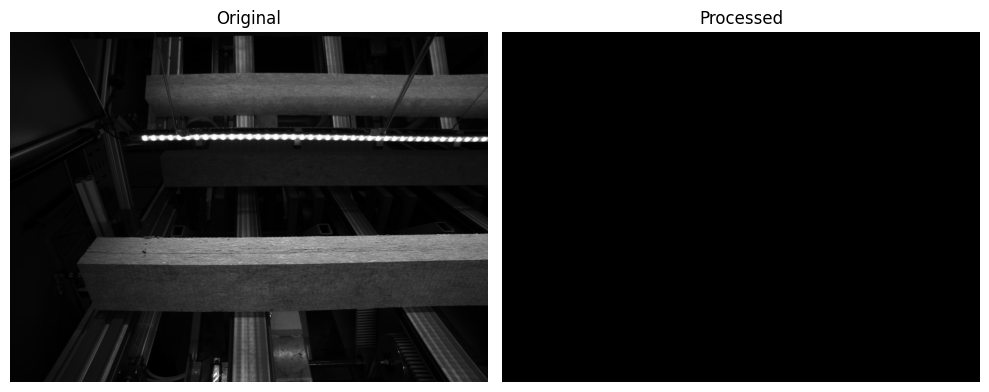

In [3]:
from utils.models.auto_anomaly.auto_anomaly import AutoAnomaly
from utils.image_tools import random_image as ra
from utils.image_tools import visualizations as vi
from matplotlib import pyplot as plt
import cv2

model = AutoAnomaly(warmup_window_size=2, 
                    area_threshold=1,
                    global_area_threshold=1,
                    use_custom_min_max=True,
                    anomaly_min=1,
                    anomaly_max=10)
# img, filename = ra.load_random_image("/mnt/nas/GBT002/front_mid_preprocessing/defective")
img = cv2.cvtColor(cv2.imread("/mnt/nas/SPA006/26_02_04/DA4214694/2026-02-04_10-10-17.779327_DA4214694-934.png"), cv2.COLOR_BGR2RGB)
overlay, mask, colored_map, discard = model.predict(img)

vi.plot_image_comparison(overlay, colored_map)